# Bài tập thực hành chính quy: Xử lý ảnh và thị giác máy tính

Notebook này là học liệu hướng dẫn và khung làm bài cho hai chủ đề:

1. Hình thái học toán học.
2. Biến đổi hình học và chống răng cưa (anti-aliasing).

Phiên bản này yêu cầu sinh viên **tự viết nhiều thành phần nền tảng**, thay vì chỉ gọi các hàm trợ giúp có sẵn. Mục tiêu là buộc sinh viên hiểu bản chất của phép toán thay vì chỉ quan sát đầu ra.


# Thiết lập chung


In [6]:
import numpy as np
import matplotlib.pyplot as plt
from jsonschema.benchmarks.const_vs_enum import value

try:
    import cv2
    HAS_CV2 = True
except ImportError:
    HAS_CV2 = False
    cv2 = None

plt.rcParams['figure.figsize'] = (6, 6)
plt.rcParams['image.cmap'] = 'gray'


In [7]:
def show_image(img, title='', cmap='gray'):
    plt.figure(figsize=(5, 5))
    if img.ndim == 2:
        plt.imshow(img, cmap=cmap)
    else:
        plt.imshow(img)
    plt.title(title)
    plt.axis('off')
    plt.show()


def show_images(images, titles=None, cols=3, cmap='gray', figsize=(14, 8)):
    n = len(images)
    rows = (n + cols - 1) // cols
    plt.figure(figsize=figsize)
    for i, img in enumerate(images):
        plt.subplot(rows, cols, i + 1)
        if img.ndim == 2:
            plt.imshow(img, cmap=cmap)
        else:
            plt.imshow(img)
        if titles is not None:
            plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()


# Ảnh kiểm thử


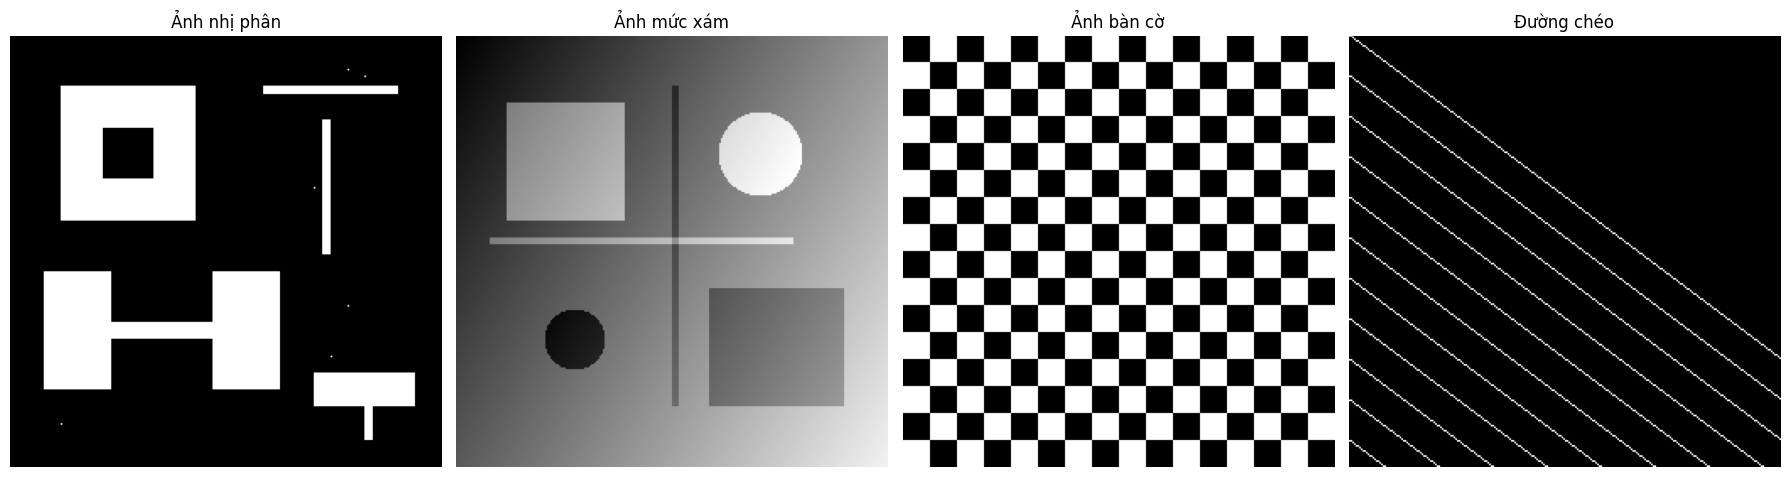

In [8]:
def make_binary_test_image(size=256):
    img = np.zeros((size, size), dtype=np.uint8)
    img[30:110, 30:110] = 255
    img[55:85, 55:85] = 0
    img[140:210, 20:60] = 255
    img[170:180, 60:120] = 255
    img[140:210, 120:160] = 255
    img[30:35, 150:230] = 255
    img[50:130, 185:190] = 255
    img[200:220, 180:240] = 255
    img[220:240, 210:215] = 255
    noise_points = [(20, 200), (24, 210), (90, 180), (160, 200), (190, 190), (230, 30)]
    for r, c in noise_points:
        img[r, c] = 255
    return img


def make_grayscale_test_image(size=256):
    y, x = np.mgrid[0:size, 0:size]
    base = 40 + 0.5 * x + 0.3 * y
    img = base.astype(np.float32)
    img[40:110, 30:100] += 80
    img[150:220, 150:230] -= 50
    rr = (x - 180) ** 2 + (y - 70) ** 2
    img[rr < 25**2] += 90
    img[(x - 70) ** 2 + (y - 180) ** 2 < 18**2] -= 70
    img[120:124, 20:200] += 60
    img[30:220, 128:132] -= 40
    img = np.clip(img, 0, 255)
    return img.astype(np.uint8)


def make_checkerboard(size=256, block=16):
    y, x = np.indices((size, size))
    board = ((x // block + y // block) % 2) * 255
    return board.astype(np.uint8)


def make_diagonal_lines(size=256):
    """Ảnh với nhiều đường chéo mảnh -- đặc biệt nhạy cảm với răng cưa."""
    img = np.zeros((size, size), dtype=np.uint8)
    for k in range(0, size, 24):
        for t in range(size):
            r = k + t * 3 // 4
            c = t
            if 0 <= r < size:
                img[r, c] = 255
    return img


binary_img = make_binary_test_image()
grayscale_img = make_grayscale_test_image()
checkerboard_img = make_checkerboard()
diagonal_img = make_diagonal_lines()

show_images(
    [binary_img, grayscale_img, checkerboard_img, diagonal_img],
    titles=['Ảnh nhị phân', 'Ảnh mức xám', 'Ảnh bàn cờ', 'Đường chéo'],
    cols=4,
    figsize=(18, 5)
)


# Bài tập 1: Hình thái học toán học

## Yêu cầu trọng tâm

Sinh viên phải tự viết:

- hàm tạo phần tử cấu trúc,
- hàm padding cho ảnh nhị phân,
- các phép erosion, dilation, opening, closing, gradient.

## Quy ước phần tử cấu trúc

Chỉ dùng ba họ:

- `rectangle`: gồm vuông, ngang, dọc,
- `cross`,
- `ellipse`.

Không dùng `diamond`.


## Việc sinh viên phải làm

1. Tự cài đặt hàm sinh phần tử cấu trúc theo kích thước bất kỳ hợp lệ.
2. Với `rectangle`, phải hỗ trợ cả trường hợp vuông, chữ nhật ngang, chữ nhật dọc.
3. Tự cài đặt padding cho ảnh nhị phân.
4. Tự cài đặt erosion, dilation, opening, closing, gradient.
5. Thử trên ảnh nhị phân kiểm thử và ảnh mẫu giảng viên cung cấp.


In [9]:
# TODO: Sinh viên tự viết hàm padding cho ảnh nhị phân

def pad_binary_image_manual(img, pad_h, pad_w, mode='constant',value = 0):
    # Yêu cầu tối thiểu:
    # - Hỗ trợ mode='constant'
    # - Có thể mở rộng thêm mode khác nếu muốn

    """
    Tham so dau vao
    img : Ma tran anh goc 2D (H,W)
    pad_h : so luong pixel dap them theo chieu doc
    pad_w : so luong pixel dep them theo chieu ngang
    mode : che do dien constant
    value : gia tri neu dung mode constant
    """

    # check mode
    if mode != 'constant':
        raise NotImplementedError("Khong dung yeu cau!")
    H,W = img.shape

    # create matrix contain 'value'
    padded_shape = (H+2 * pad_h , W+2 * pad_w)
    padded_img = np.full(padded_shape, fill_value=value, dtype=img.dtype)

    # copy original image to the center of the padded matrix
    padded_img[pad_h : pad_h + H , pad_w : pad_w + W] = img

    return padded_img


In [10]:
# TODO: Sinh viên tự viết hàm tạo phần tử cấu trúc

def make_structuring_element(shape, ksize):
    # shape thuộc một trong ba giá trị: 'rectangle', 'cross', 'ellipse'
    # ksize là bộ (height, width)

    kh, kw = ksize

    #init matrix for se with all 0
    se = np.zeros((kh,kw),dtype=np.uint8)

    #toa do tam cua se
    center_h = (kh - 1) / 2.0
    center_w = (kw - 1) / 2.0

    # rectangle area with all cell 1
    if shape == 'rectangle':
        se[:] = 1

    # cross area with middle rows and middle column 1
   z` elif shape == 'cross':
        se[int(center_h),:] = 1
        se[:,int(center_w)] = 1

    # ellipse area
    elif shape == 'ellipse':
        r_radius = kh / 2.0
        c_radius = kw / 2.0
        for r in range(kw):
            if((r-center_h) / r_radius ** 2) + ((c - center_w)/c_radius ** 2) <= 1.0:
                se[r, c] = 1
    else:
        raise ValueError("Hinh SE khong hop le")
    return se


In [11]:
# TODO: Sinh viên tự hoàn thiện các phép toán hình thái học

def erosion_binary(img, se):
    """
    Phép Co ảnh nhị phân thủ công sử dụng vòng lặp.
    Lấy giá trị MIN của các pixel lân cận nằm trong vùng SE = 1
    """
    H, W = img.shape
    kh, kw = se.shape
    pad_h, pad_w = kh // 2, kw // 2

    padded = pad_binary_image_manual(img, pad_h, pad_w, mode='constant', value=255)
    out = np.zeros_like(img)

    # Duyet tung pixel tren anh
    for r in range(H):
        for c in range(W):
            # cat vung lan can tuong thich voi anh
            patch = padded[r : r + kh, c : c + kw]
            # chi lay pixel tai se == 1 va lay diem nho nhat
            out[r, c] = np.min(patch[se == 1])

    return out


def dilation_binary(img, se):
    """
    Phép Giãn ảnh nhị phân thủ công sử dụng vòng lặp.
    Lấy giá trị MAX của các pixel lân cận nằm trong vùng SE = 1.
    """
    H, W = img.shape
    kh, kw = se.shape
    pad_h, pad_w = kh // 2, kw // 2

    # Vien dien 0 cho phep gian de tranh nhieu
    padded = pad_binary_image_manual(img, pad_h, pad_w, mode='constant', value=0)
    out = np.zeros_like(img)

    # Duyet tung pixel
    for r in range(H):
        for c in range(W):
            patch = padded[r : r + kh, c : c + kw]
            # chi lay cac pixel tai diem se == 1 va gia tri lon nhat
            out[r, c] = np.max(patch[se == 1])
    return out

def opening_binary(img, se):
    """
    Phép Mở nhị phân: Co trước (Erosion), Giãn sau (Dilation).
    """
    # co truoc va gian sau
    eroded_img = erosion_binary(img, se)
    opened_img = dilation_binary(eroded_img, se)
    return opened_img

def closing_binary(img, se):
    """
    Phép Đóng nhị phân: Giãn trước (Dilation), Co sau (Erosion).
    """
    # Gian truoc va co sau
    dilated_img = dilation_binary(img, se)
    closed_img = erosion_binary(dilated_img, se)
    return closed_img


def morphological_gradient_binary(img, se):
    """
    Gradient Hình thái học: Phép Giãn trừ Phép Co để trích xuất đường biên.
    """
    dilated_img = dilation_binary(img, se)
    eroded_img = erosion_binary(img, se)

    # Ep kieu de tranh hien tuong tran so
    gradient = dilated_img.astype(np.int16) - eroded_img.astype(np.int16)
    # Gioi han gia tri trong [0,255] va ep ve kieu chuan unit8
    gradient = np.clip(gradient, 0, 255).astype(np.uint8)
    return gradient


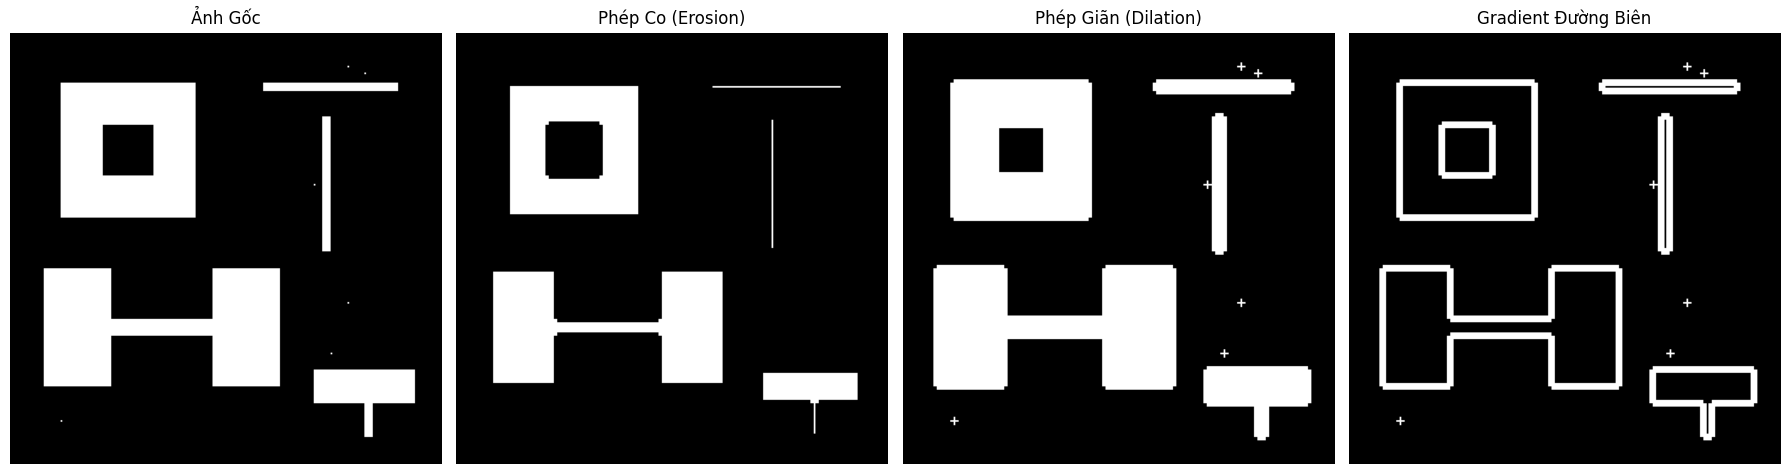

In [12]:
# Ô thực hành gợi ý
# Sau khi hoàn thiện các hàm ở trên, sinh viên tự chạy các thử nghiệm ở đây.

# Ví dụ khung:
# se = make_structuring_element('rectangle', (3, 7))
# out = opening_binary(binary_img, se)
# show_images([binary_img, out], ['Đầu vào', 'Opening với rectangle 3x7'])

# Tạo một phần tử cấu trúc hình chữ thập kích thước 5x5 làm mẫu
se_cross = make_structuring_element('cross', (5, 5))

# Tiến hành chạy thử nghiệm các hàm vừa viết trên ảnh nhị phân mẫu 'binary_img'
img_erosion = erosion_binary(binary_img, se_cross)
img_dilation = dilation_binary(binary_img, se_cross)
img_gradient = morphological_gradient_binary(binary_img, se_cross)

# Hiển thị so sánh trực quan
show_images(
    [binary_img, img_erosion, img_dilation, img_gradient],
    titles=['Ảnh Gốc', 'Phép Co (Erosion)', 'Phép Giãn (Dilation)', 'Gradient Đường Biên'],
    cols=4,
    figsize=(18, 5)
)

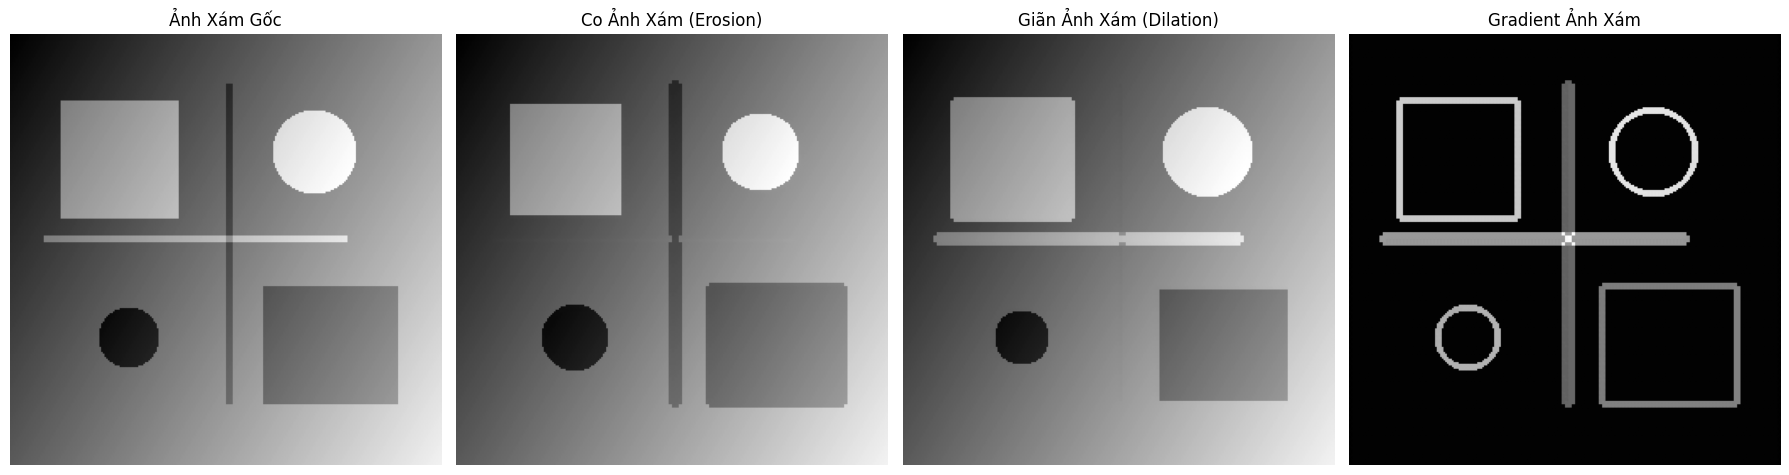

In [13]:
# Thu nghiem voi "ANH MUC XAM"
gray_erosion  = erosion_binary(grayscale_img, se_cross)
gray_dilation = dilation_binary(grayscale_img, se_cross)
gray_gradient = morphological_gradient_binary(grayscale_img, se_cross)

show_images(
    [grayscale_img, gray_erosion, gray_dilation, gray_gradient],
    titles=['Ảnh Xám Gốc', 'Co Ảnh Xám (Erosion)', 'Giãn Ảnh Xám (Dilation)', 'Gradient Ảnh Xám'],
    cols=4, figsize=(18, 5)
)

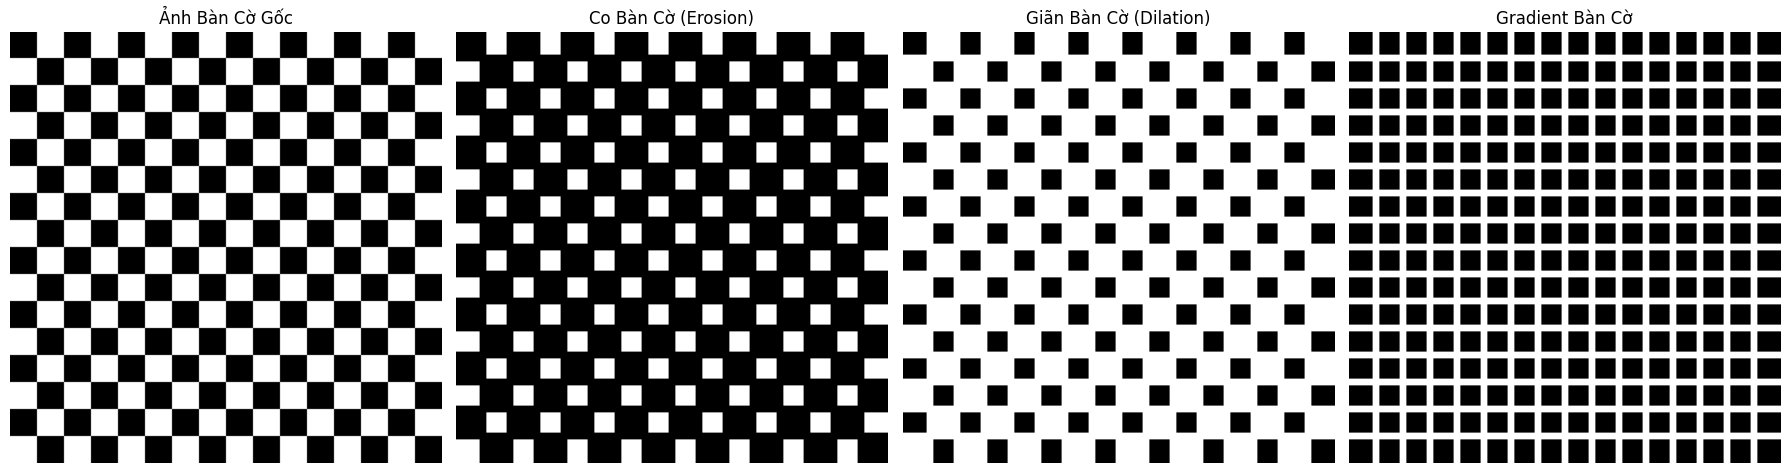

In [15]:
# Thu nghiem voi anh ban co
checker_erosion  = erosion_binary(checkerboard_img, se_cross)
checker_dilation = dilation_binary(checkerboard_img, se_cross)
checker_gradient = morphological_gradient_binary(checkerboard_img, se_cross)
show_images(
    [checkerboard_img, checker_erosion, checker_dilation, checker_gradient],
    titles=['Ảnh Bàn Cờ Gốc', 'Co Bàn Cờ (Erosion)', 'Giãn Bàn Cờ (Dilation)', 'Gradient Bàn Cờ'],
    cols=4, figsize=(18, 5)
)

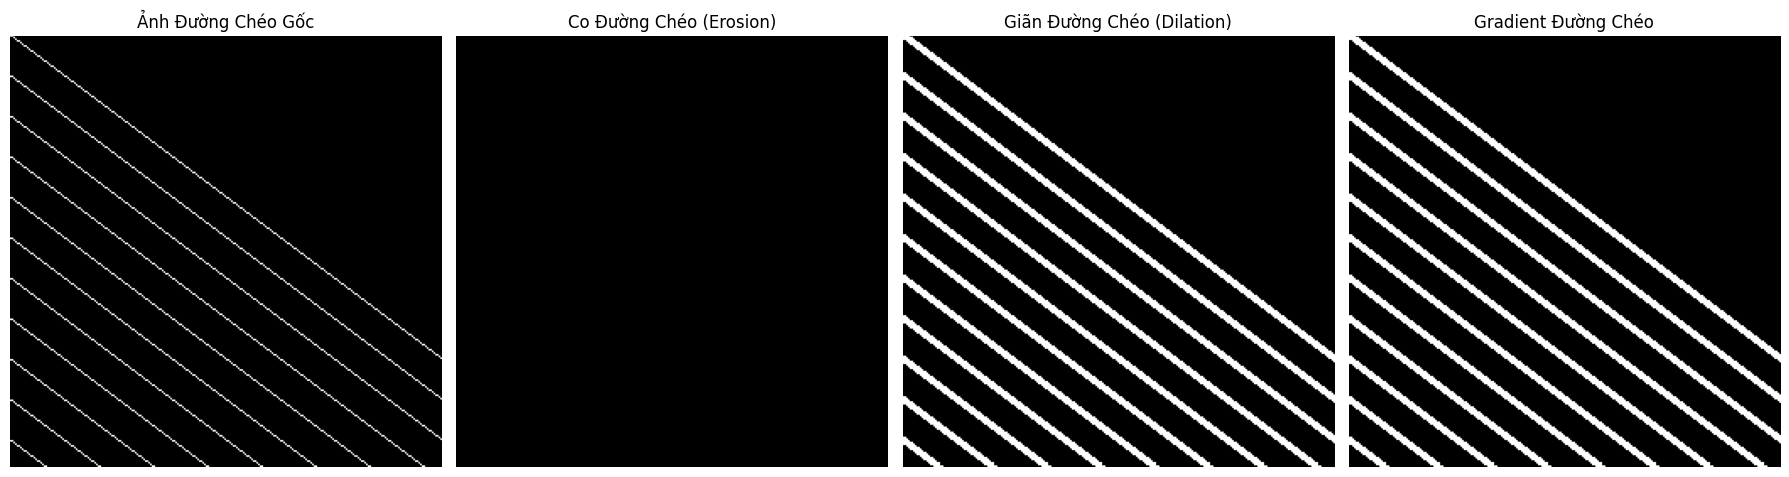

In [16]:
# Thu nghiem voi anh duong cheo manh
diagonal_erosion  = erosion_binary(diagonal_img, se_cross)
diagonal_dilation = dilation_binary(diagonal_img, se_cross)
diagonal_gradient = morphological_gradient_binary(diagonal_img, se_cross)

show_images(
    [diagonal_img, diagonal_erosion, diagonal_dilation, diagonal_gradient],
    titles=['Ảnh Đường Chéo Gốc', 'Co Đường Chéo (Erosion)', 'Giãn Đường Chéo (Dilation)', 'Gradient Đường Chéo'],
    cols=4, figsize=(18, 5)
)

Nhận xét từng kết quả hình thái học theo 4 mẫu giảng viên đã cho trước

1. Ảnh nhị phân:
* Với phép co : Thu hẹp vùng trắng , xóa sạch hoàn toàn các chấm nhiễu sáng cô lập, làm rộng các lỗ trống đen bên trong vật thể
* Với phép giãn : Phình to vùng trắng, lấp đầy các lỗ trống đen nhỏ, nhưng vô tình phóng đại các đốm nhiễu sáng
* Gradiant : Loại bỏ toàn bộ vùng ruột đặc bên trong và nền phẳng, chỉ giữ lại đường viền bao quanh vật thể
2. Ảnh mức xám:
* Với phép co : Toàn bộ ảnh bị tối đi do toán tử min chọn cường độ thấp nhất trong cửa sổ; các chi tiết sáng bị thu hẹp biên
* Với phép giãn: Toàn bộ ảnh sáng lên do toán tử max chọn cường độ cao nhất; các thung lũng tối hoặc rãnh hẹp bị lấp đầy
* Gradiant: Trích xuất lược đồ độ tương phản biên, các vùng có mức xám thay đổi đột ngột (cạnh sắc) hiện rõ, vùng đồng nhất biến thành đen
3. Ảnh bàn cờ:
* Với Phép Co : Ô trắng thu hẹp, ô đen phình to, các góc vuông 90 độ của ô trắng bị bo tròn lùi vào trong theo dạng bậc thang do hình dáng chữ thập của SE
* Với Phép Giãn : Ô trắng phình to lấn át ô đen, các góc vuông của ô đen bị bo tròn ngược lại
* Gradient: Tạo thành một hệ thống lưới khung dây đối xứng, bao trọn chính xác các đường ranh giới giữa các ô cờ
4. Ảnh đường chéo mảnh:
* Với Phép Co : Các đường chéo biến mất hoàn toàn (ảnh tối đen) vì độ dày mảnh 1 pixel nhỏ hơn bán kính SE, bị toán tử min triệt tiêu về 0
* Với Phép Giãn : Các đường chéo được làm dày lên mạnh mẽ nhưng bị thô và xuất hiện răng cưa bậc thang dọc theo hướng SE phát triển
* Gradient: Trùng khớp hoàn toàn với kết quả của phép Giãn vì ảnh phép Co đã bằng 0 (Giãn - 0 = Giãn)

# Bài tập 2: Biến đổi hình học và Chống Răng Cưa

Bài tập này xây dựng toàn bộ pipeline biến đổi hình học có anti-aliasing.

## Phân biệt hai cơ chế cốt lõi

| Cơ chế | Kernel | Hàm dùng |
|---|---|---|
| **Tích chập** (`convolution`) | Cố định, không đổi theo vị trí | `convolve2d_manual` gọi **một lần** cho cả ảnh |
| **Tích vô hướng cục bộ** (`local dot product`) | Thay đổi theo $\delta_r, \delta_c$ của từng pixel | Tính **bên trong vòng lặp** của `warp_affine_manual` |

- **Nearest, Bilinear, SSAA** → kernel cố định hoặc không cần kernel → `convolve2d_manual` có thể dùng.
- **Bicubic, Lanczos** → kernel phụ thuộc vào phần lẻ $\delta$ của tọa độ nguồn → **không thể** gọi `convolve2d_manual` một lần toàn ảnh; phải tính cục bộ mỗi pixel.

## Việc sinh viên phải làm

1. Cài đặt ít nhất hai phép biến đổi affine (bắt buộc có quay và co giãn/shear).
2. Cài đặt `nearest_interpolate` và `bilinear_interpolate`.
3. **Tự viết** `convolve2d_manual` bằng vòng lặp (dùng cho SSAA và làm mượt sau warp).
4. Cài đặt `warp_affine_manual` dùng ánh xạ ngược.
5. Cài đặt `warp_affine_ssaa` dùng `convolve2d_manual` (tích chập cố định).
6. Cài đặt `bicubic_interpolate` và `lanczos_interpolate` (tích vô hướng cục bộ).
7. Tích hợp bicubic/Lanczos vào `warp_affine_manual` qua tham số `interpolation`.

## Ràng buộc

- Không dùng `cv2.warpAffine`, `scipy.ndimage.affine_transform`, `skimage.transform.warp`.
- Không dùng `scipy.signal.convolve2d`, `np.convolve` hay hàm tích chập có sẵn -- phải tự viết vòng lặp.
- Không chọn biến đổi quá tầm thường (quay 0°) làm ví dụ chính.


## Phần A -- Nội suy và tích chập nền tảng

### nearest_interpolate / bilinear_interpolate
**Cơ chế:** tích vô hướng cục bộ với cửa sổ cố định ($1\times1$ và $2\times2$).  
Kernel không phụ thuộc vào $\delta$ theo cách phức tạp -- bilinear dùng
$\mathbf{w}_r = [1-\delta_r, \delta_r]$ và $\mathbf{w}_c = [1-\delta_c, \delta_c]$,
tích ngoài cho ma trận $2\times2$.

### convolve2d_manual
**Cơ chế:** tích chập thực sự -- kernel **cố định**, trượt qua toàn ảnh.  
Dùng cho SSAA (kernel hộp $L\times L$) và làm mượt sau warp (kernel Gaussian).  
**Không phù hợp** cho Bicubic/Lanczos vì kernel của chúng thay đổi mỗi pixel.




In [19]:
def translation_matrix(tx, ty):
    return np.array([
        [1, 0, tx],
        [0, 1, ty],
        [0, 0, 1]
    ], dtype=np.float32)


def scaling_matrix(sx, sy):
    return np.array([
        [sx, 0, 0],
        [0, sy, 0],
        [0, 0, 1]
    ], dtype=np.float32)


def rotation_matrix(deg):
    rad = np.deg2rad(deg)
    c, s = np.cos(rad), np.sin(rad)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ], dtype=np.float32)


def shear_matrix(shx=0.0, shy=0.0):
    return np.array([
        [1, shx, 0],
        [shy, 1, 0],
        [0, 0, 1]
    ], dtype=np.float32)


In [21]:
# TODO: Sinh viên tự hoàn thiện nội suy

def nearest_interpolate(img, x, y):
    """
    Nội suy nearest-neighbor tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng 1x1 -- chọn pixel nguyên gần nhất.
    Không phụ thuộc vào delta; không cần xây kernel.

    Trả về: float, giá trị tại pixel gần nhất.
    """

    H, W = img.shape

    # Lam tron toa do tu so thuc ve so nguyen
    r = int(np.floor(y + 0.5))
    c = int(np.floor(x + 0.5))

    # Kiem tra bien de khong bi tran ra khoi matrix
    r = max(0, min(r, H - 1))
    c = max(0, min(c, W - 1))
    return float(img[r, c])


def bilinear_interpolate(img, x, y):
    """
    Nội suy bilinear tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ 2x2.
    - delta_c = x - floor(x),  delta_r = y - floor(y)
    - w_c = [1-delta_c, delta_c]  (vector hàng)
    - w_r = [1-delta_r, delta_r]  (vector cột)
    - Patch P = I[floor(y):floor(y)+2, floor(x):floor(x)+2]
    - Kết quả = w_r @ P @ w_c  (tích vô hướng, KHÔNG phải tích chập)

    Trả về: float, clamp về [0, 255].
    """
    H, W = img.shape

    #Xac dinh vi tri pixel o duoi nen
    r0 = int(np.floor(y))
    c0 = int(np.floor(x))

    #Xac dinh vi tri lan can tiep theo trong bien anh
    r1 = min(r0 + 1, H - 1)
    c1 = min(c0 + 1, W - 1)

    #Dam bao r0 va c0 khong vuot qua bien ben trai va o tren
    r0 = max(0, min(r0, H - 1))
    c0 = max(0, min(c0, W - 1))

    dr = y - r0
    dc = x - c0

    #Lay gia tri 4 pixel lan can
    Q00 = img[r0, c0]
    Q01 = img[r0, c1]
    Q10 = img[r1, c0]
    Q11 = img[r1, c1]

    val = (1 - dr) * (1 - dc) * Q00 + \
          (1 - dr) * dc * Q01 + \
          dr * (1 - dc) * Q10 + \
          dr * dc * Q11
    #Gioi han gia tri tra ve trong khoang[0,255]
    return float(np.clip(val, 0, 255))


In [20]:
# TODO: Sinh viên tự viết tích chập 2D bằng vòng lặp
# Không được dùng bất kỳ hàm tích chập có sẵn nào.

def convolve2d_manual(img, kernel, pad_mode='constant', pad_value=0):
    """
    Tích chập 2D thủ công -- kernel CỐ ĐỊNH, trượt qua toàn ảnh.

    Dùng cho:
      - SSAA: kernel = np.ones((L,L))/L**2  (box filter)
      - Làm mượt sau warp: kernel = gaussian_kernel(n)
    KHÔNG dùng cho Bicubic/Lanczos (kernel của chúng thay đổi theo delta).

    Tham số
    -------
    img       : np.ndarray (H, W), kiểu float
    kernel    : np.ndarray (kH, kW)  -- cố định, không phụ thuộc vào vị trí
    pad_mode  : 'constant' -- điền pad_value ngoài biên
    pad_value : giá trị điền khi pad_mode='constant'

    Trả về
    ------
    out : np.ndarray (H, W), cùng kiểu với img

    Gợi ý các bước
    --------------
    1. Lật kernel 180° (flip cả hàng lẫn cột) -- đây là điểm khác biệt
       giữa convolution và cross-correlation.
    2. Pad ảnh đầu vào đủ để giữ nguyên kích thước đầu ra.
    3. Duyệt từng pixel (r, c), tính tổng trọng số cửa sổ kernel.
    """
    if pad_mode != 'constant':
        raise NotImplementedError("Khong dung yeu cau!")
    H,W = img.shape
    kh,kw =kernel.shape
    pad_h , pad_w = kh//2 , kw //2

    # Lat kernal 180 do
    kernel_flipped = np.flipud(kernel)

    # Pad anh dau vao de giu nguyen kich thuoc dau ra
    padded_img = np.pad(img, ((pad_h, pad_h), (pad_w, pad_w)), mode='constant', constant_values=pad_value)
    out = np.zeros_like(img, dtype=np.float32)

    # Duyet tung pixel tren tich chap
    for r in range(H):
        for c in range(W):
            # Cat vung lan can co kich thuoc = kernal
            patch = padded_img[r : r + kh, c : c + kw]
            # Nhan tung phan tu voi kernel da lat va tinh sum
            out[r, c] = np.sum(patch * kernel_flipped)
    return out.astype(img.dtype)

In [22]:
# TODO: Sinh viên tự hoàn thiện warp affine bằng ánh xạ ngược

def warp_affine_manual(img, matrix, out_shape, interpolation='nearest', fill_value=0):
    """
    Biến đổi affine dùng ánh xạ ngược.

    Pipeline cho mỗi pixel đích (r', c'):
      [x, y, 1]^T = matrix^{-1} @ [c', r', 1]^T
      if (x, y) ngoài biên: gán fill_value
      else: gọi hàm nội suy phù hợp

    Phân biệt cơ chế theo interpolation:
      'nearest'  -> nearest_interpolate(img, x, y)
                    [tích vô hướng 1x1, không cần delta]
      'bilinear' -> bilinear_interpolate(img, x, y)
                    [tích vô hướng 2x2, w = f(delta)]
      'bicubic'  -> bicubic_interpolate(img, x, y)
                    [tích vô hướng 4x4, kernel = R(delta-i) -- thay đổi mỗi pixel]
      'lanczos'  -> lanczos_interpolate(img, x, y)
                    [tích vô hướng (2a)x(2a), kernel = L(delta-i) -- thay đổi mỗi pixel]

    Lưu ý: SSAA dùng hàm riêng warp_affine_ssaa, không qua đây.

    interpolation : 'nearest' | 'bilinear' | 'bicubic' | 'lanczos'
    """
    out_h, out_w = out_shape
    H, W = img.shape

    # khoi tao ma tran anh dich voi gia tri fill_value
    out = np.full((out_h, out_w), fill_value=fill_value, dtype=img.dtype)

    # Tinh ma tran nghich dao M^(-1) truoc vung lap de tang toc do xu ly
    try:
        inv_matrix = np.linalg.inv(matrix)
    except np.linalg.LinAlgError:
        raise ValueError("Ma tran bien doi khong the nghich dao")

    # Duyet qua tung pixel dich (r', c')
    for r_prime in range(out_h):
        for c_prime in range(out_w):
            # Xay dung vector toa do dong nhat [c', r', 1]^T
            #  c_prime la truc x ,  r_prime la truc y
            tgt_coord = np.array([c_prime, r_prime, 1.0], dtype=np.float32)

            # nhan ma tran de tim nguon thuc
            src_coord = inv_matrix @ tgt_coord
            x, y = src_coord[0], src_coord[1]

            # Kiem tra toa do co nam trong anh goc kh
            if 0 <= x < W and 0 <= y < H:
                if interpolation == 'nearest':
                    out[r_prime, c_prime] = nearest_interpolate(img, x, y)
                elif interpolation == 'bilinear':
                    out[r_prime, c_prime] = bilinear_interpolate(img, x, y)
                elif interpolation == 'bicubic':
                    out[r_prime, c_prime] = bicubic_interpolate(img, x, y)
                elif interpolation == 'lanczos':
                    out[r_prime, c_prime] = lanczos_interpolate(img, x, y)
                else:
                    raise ValueError(f"Phương thức nội suy '{interpolation}' không được hỗ trợ.")
            else:
                # neu nam ngoai bien anh nguon thi giu nguyen fill_value
                out[r_prime, c_prime] = fill_value
    return out


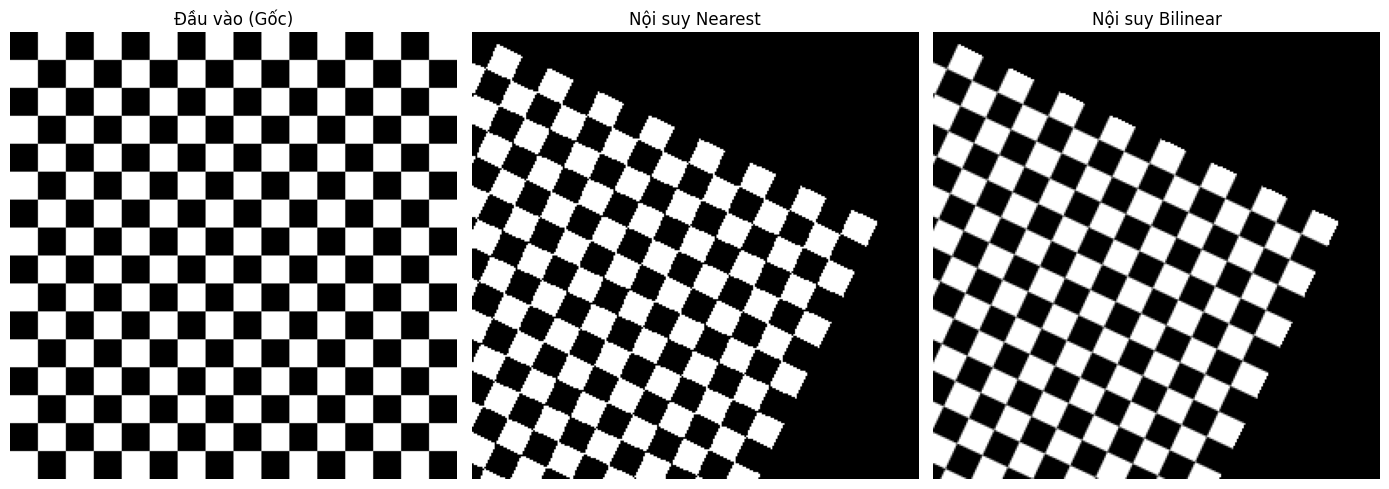

In [23]:
# Ô kiểm tra nhanh Phần A
# Ví dụ khung:
# M = rotation_matrix(25)
# out_nn = warp_affine_manual(checkerboard_img.astype(np.float32), M, checkerboard_img.shape, interpolation='nearest')
# out_bl = warp_affine_manual(checkerboard_img.astype(np.float32), M, checkerboard_img.shape, interpolation='bilinear')
# show_images([checkerboard_img, out_nn, out_bl], ['Đầu vào', 'Nearest', 'Bilinear'])

# Khoi tao ma tran xoay 25 do quanh toa do goc
M = rotation_matrix(25)

# ep keiu anh sang float 32 de tranh loi lam tron khi tinh toan noi suy
img_input = checkerboard_img.astype(np.float32)

# Thuc hien xoay anh bang phuong phap nearest neighbor
out_nn = warp_affine_manual(img_input, M, checkerboard_img.shape, interpolation='nearest')

# thuc hien xoay anh bang phuong phap noi suy tuyen tinh 2 chieu bilinear
out_bl = warp_affine_manual(img_input, M, checkerboard_img.shape, interpolation='bilinear')

show_images(
    [checkerboard_img, out_nn, out_bl],
    ['Đầu vào (Gốc)', 'Nội suy Nearest', 'Nội suy Bilinear'],
    cols=3,
    figsize=(14, 5)
)


## Phần B -- Anti-aliasing qua nội suy nâng cao

Khi xoay hoặc phóng to ảnh, các đường chéo và cạnh cong trông gồ ghề
(răng cưa / jaggies). Nguyên nhân: tọa độ nguồn $(y, x)$ sau ánh xạ ngược
không trùng với lưới pixel -- phần lẻ $\delta$ khác nhau mỗi pixel đích.

### Hai cách chống răng cưa

**Cách 1 -- Tích chập cố định (SSAA):**  
Warp bằng nearest, rồi gọi `convolve2d_manual` với kernel hộp.  
Kernel không thay đổi → có thể dùng `convolve2d_manual` một lần.

**Cách 2 -- Tích vô hướng cục bộ với kernel thay đổi (Bicubic, Lanczos):**  
Bên trong vòng lặp của `warp_affine_manual`, mỗi pixel đích tính
$(\delta_r, \delta_c)$, xây weight vector $w_r, w_c$, rồi thực hiện
tích vô hướng với patch $4\times4$ hoặc $(2a)\times(2a)$.  
Kernel thay đổi mỗi pixel → **không thể** gọi `convolve2d_manual` toàn ảnh.


### Kỹ thuật 1: Supersampling Anti-Aliasing (SSAA) -- tích chập cố định

**Ý tưởng:** Lấy $L^2$ mẫu đều nhau trong diện tích pixel đích, mỗi mẫu
ánh xạ ngược về ảnh nguồn và nội suy bilinear, rồi trung bình.

$$C(r', c') = \frac{1}{L^2}\sum_{m=0}^{L-1}\sum_{n=0}^{L-1}
f\!\left(r'+\frac{m+0.5}{L},\;c'+\frac{n+0.5}{L}\right)$$

**Liên hệ với tích chập:** SSAA tương đương áp bộ lọc hộp $L\times L$
lên ảnh đã warp nearest. Kernel hộp **không phụ thuộc** vào $\delta$ --
nó như nhau tại mọi pixel:
$$K_{\text{box}}^{(L)} = \frac{1}{L^2}\mathbf{1}_{L\times L}$$

Vì vậy `warp_affine_ssaa` có thể được cài đặt theo một trong hai cách:
- **Cách A (khuyến khích):** warp nearest → `convolve2d_manual(warped, K_box)`.
- **Cách B:** vòng lặp $L^2$ mẫu mỗi pixel (theo công thức trên).

Cả hai cho cùng kết quả; Cách A tái sử dụng hàm đã viết.


In [24]:
# TODO: Sinh viên tự cài đặt SSAA

def warp_affine_ssaa(img, matrix, out_shape, L=2, fill_value=0):
    """
    Biến đổi affine với Supersampling Anti-Aliasing.

    Với mỗi pixel đích (r', c'), lấy L*L mẫu con đều nhau trong
    diện tích pixel, ánh xạ ngược từng mẫu con về ảnh nguồn,
    nội suy bilinear, rồi lấy trung bình.

    Gợi ý: offset mẫu con thứ (m, n) tại pixel (r', c') là
        (r' + (m + 0.5) / L,  c' + (n + 0.5) / L)
    trước khi ánh xạ ngược qua matrix^{-1}.

    L : int -- hệ số supersampling (L=2 => 4 mẫu/pixel, L=4 => 16 mẫu/pixel)
    """
    out_h, out_w = out_shape
    H, W = img.shape

    # Khoi tao ma tran anh dich
    out = np.full((out_h, out_w), fill_value=fill_value, dtype=img.dtype)

    # Tinh ma tran nghich dao M^(-1)
    try:
        inv_matrix = np.linalg.inv(matrix)
    except np.linalg.LinAlgError:
        raise ValueError("Ma tran bien doi khong the nghich dao.")

    # Tong so mau con trong mot pixel
    num_samples = L * L

    # Duyet qua tung pixel dich (r', c')
    for r_prime in range(out_h):
        for c_prime in range(out_w):
            total_val = 0.0

            # Duyet qua luoi L x L mau con ben trong dien tich cua pixel dich
            for m in range(L):
                for n in range(L):
                    # Tinh toa do thuc min (sub-pixel) cua mau con theo cong thuc
                    sub_r = r_prime + (m + 0.5) / L
                    sub_c = c_prime + (n + 0.5) / L

                    # Tao vector toa do dong nhat [sub_c, sub_r, 1]^T
                    tgt_coord = np.array([sub_c, sub_r, 1.0], dtype=np.float32)

                    # Anh xa nguoc ve anh goc
                    src_coord = inv_matrix @ tgt_coord
                    x, y = src_coord[0], src_coord[1]

                    # Kiem tra bien anh nguon
                    if 0 <= x < W and 0 <= y < H:
                        # Noi suy bilinear cho mau con nay va tich luy gia tri
                        total_val += bilinear_interpolate(img, x, y)
                    else:
                        # Neu mau con vang ra ngoai bien, tich luy gia tri fill_value
                        total_val += fill_value

            # Lay trung binh cong cua L^2 mau con va gan cho pixel dich
            out[r_prime, c_prime] = np.clip(total_val / num_samples, 0, 255)
    return out

### Kỹ thuật 2: Bicubic -- tích vô hướng cục bộ $4\times4$

**Ý tưởng:** Dùng cửa sổ $4\times4$ pixel lân cận và hàm trọng số
cubic $R(d)$ (Keys) thay vì trung bình đều.

**Hàm trọng số 1D** ($a = -0.5$):
$$R(d) = \begin{cases}
(a+2)|d|^3 - (a+3)|d|^2 + 1 & |d| \leq 1 \\
a|d|^3 - 5a|d|^2 + 8a|d| - 4a & 1 < |d| < 2 \\
0 & \text{còn lại}
\end{cases}$$

**Tại sao không dùng `convolve2d_manual`?**  
Tại mỗi pixel đích, $\delta_r$ và $\delta_c$ khác nhau.  
Weight vector $\mathbf{w}_r = [R(\delta_r+1),\,R(\delta_r),\,R(\delta_r-1),\,R(\delta_r-2)]$
thay đổi theo $\delta_r$ -- kernel không cố định.  
Phải tính bên trong vòng lặp của `warp_affine_manual`.

**Công thức tích vô hướng cục bộ:**
$$P(y,x) = \mathbf{w}_r^T \cdot I_{\text{patch}} \cdot \mathbf{w}_c$$
trong đó $I_{\text{patch}}$ là ma trận $4\times4$ pixel lân cận.  
Không cần lật kernel (đây là tích vô hướng, không phải tích chập).


In [25]:
# TODO: Sinh viên tự cài đặt Bicubic

def cubic_kernel(d, a=-0.5):
    """
    Hàm trọng số bicubic 1D tại khoảng cách d -- Keys cubic.

    Trả về R(d) theo công thức piecewise.
    Kiểm tra: R(0)=1, R(1)=0, R(1.5)=-0.0625 với a=-0.5.
    """
    abs_d = np.abs(d)

    if abs_d <= 1.0:
        return (a + 2.0) * (abs_d**3) - (a + 3.0) * (abs_d**2) + 1.0
    elif 1.0 < abs_d < 2.0:
        return a * (abs_d**3) - 5.0 * a * (abs_d**2) + 8.0 * a * abs_d - 4.0 * a
    else:
        return 0.0


def bicubic_interpolate(img, x, y, a=-0.5):
    """
    Nội suy bicubic tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ 4x4 -- KHÔNG phải tích chập.
    - delta_r = y - floor(y),  delta_c = x - floor(x)
    - w_r[i] = cubic_kernel(delta_r - i)  cho i in {-1, 0, 1, 2}
    - w_c[j] = cubic_kernel(delta_c - j)  cho j in {-1, 0, 1, 2}
    - Patch P = I[floor(y)-1 : floor(y)+3, floor(x)-1 : floor(x)+3]
    - Kết quả = w_r @ P @ w_c  (tích vô hướng ma trận)

    Không cần lật kernel (khác với convolve2d_manual).
    Clamp kết quả về [0, 255].
    """
    H, W = img.shape

    # Xac dinh phan nguyen nen
    r0 = int(np.floor(y))
    c0 = int(np.floor(x))

    # Tinh phan le delta
    dr = y - r0
    dc = x - c0

    # hoi tao va tinh toan vector trong so hang (w_r) va cot (w_c)
    w_r = np.zeros(4, dtype=np.float32)
    w_c = np.zeros(4, dtype=np.float32)

    # Duyet qua cac offset tu -1 den 2 de tinh trong so
    for idx, i in enumerate([-1, 0, 1, 2]):
        w_r[idx] = cubic_kernel(dr - i, a)
        w_c[idx] = cubic_kernel(dc - i, a)

    # Xay dung ma tran Patch 4x4 tu anh goc (co kep bien bao ve chi muc)
    P = np.zeros((4, 4), dtype=np.float32)
    for idx_r, i in enumerate([-1, 0, 1, 2]):
        for idx_c, j in enumerate([-1, 0, 1, 2]):
            # Kep chi muc index de khong bi vang ra ngoai bien ma tran anh
            r_idx = max(0, min(r0 + i, H - 1))
            c_idx = max(0, min(c0 + j, W - 1))
            P[idx_r, idx_c] = img[r_idx, c_idx]

    # Thuc hien tich vo huong ma tran: w_r^T @ P @ w_c
    val = w_r @ P @ w_c

    # Gioi han gia tri pixel ve chuan [0, 255]
    return float(np.clip(val, 0, 255))

### Kỹ thuật 3: Lanczos -- tích vô hướng cục bộ $(2a)\times(2a)$

**Ý tưởng:** Dùng hàm sinc cửa sổ hoá -- xấp xỉ bộ lọc thông thấp lý tưởng.

**Hàm trọng số 1D** ($a = 2$ hoặc $3$):
$$L(x) = \begin{cases}
1 & x = 0 \\
\operatorname{sinc}(x)\cdot\operatorname{sinc}(x/a) & 0 < |x| < a \\
0 & |x| \geq a
\end{cases}$$
với $\operatorname{sinc}(x) = \sin(\pi x)/(\pi x)$.  
Gợi ý: `np.sinc(x)` trong NumPy đã là sinc chuẩn hoá (đã nhân $\pi$).

**Tại sao không dùng `convolve2d_manual`?**  
Giống bicubic: $\mathbf{w}_r[i] = L(\delta_r - i)$ thay đổi theo $\delta_r$
của từng pixel -- kernel không cố định.

**Công thức tích vô hướng cục bộ có chuẩn hoá:**
$$P(y,x) = \frac{\sum_i\sum_j I[\lfloor y\rfloor+i,\,\lfloor x\rfloor+j]\cdot w_r[i]\cdot w_c[j]}{\sum_i\sum_j w_r[i]\cdot w_c[j]}$$

Chuẩn hoá bắt buộc gần biên ảnh (một số pixel nằm ngoài biên bị bỏ qua,
tổng trọng số nhỏ hơn 1 nếu không chuẩn hoá).


In [30]:
# TODO: Sinh viên tự cài đặt Lanczos

def lanczos_kernel(x, a=3):
    """
    Hàm trọng số Lanczos 1D tại khoảng cách x.

    Trả về L(x) = sinc(x) * sinc(x/a) nếu |x| < a, else 0.
    Gợi ý: np.sinc(x) = sin(pi*x)/(pi*x), đã chuẩn hoá.
    Kiểm tra: L(0)=1, L(1)=0, L(0.5) > 0.
    """
    abs_x = np.abs(x)
    if abs_x == 0.0:
        return 1.0
    elif abs_x < a:
        # np.sinc cua NumPy da tu dong nhan pi ben trong
        return float(np.sinc(abs_x) * np.sinc(abs_x / a))
    else:
        return 0.0


def lanczos_interpolate(img, x, y, a=3):
    """
    Nội suy Lanczos tại tọa độ thực (x=cột, y=hàng).

    Cơ chế: tích vô hướng cục bộ (2a)x(2a) CÓ chuẩn hoá -- KHÔNG phải tích chập.
    - delta_r = y - floor(y),  delta_c = x - floor(x)
    - i in {-a+1, ..., a}: w_r[i] = lanczos_kernel(delta_r - i, a)
    - j in {-a+1, ..., a}: w_c[j] = lanczos_kernel(delta_c - j, a)
    - Tổng = sum_i sum_j I[floor(y)+i, floor(x)+j] * w_r[i] * w_c[j]
    - Chia cho sum_i sum_j w_r[i] * w_c[j]  (chuẩn hoá -- quan trọng gần biên)

    Không cần lật kernel.
    Clamp kết quả về [0, 255].
    """
    H, W = img.shape

    # Xac dinh phan nguyen nen
    r0 = int(np.floor(y))
    c0 = int(np.floor(x))

    # Tinh phan le delta
    dr = y - r0
    dc = x - c0

    # Dinh nghia tap hop cac index offset chay tu -a+1 den a
    offsets = list(range(-a + 1, a + 1))

    # Khoi tao va tinh san vector trong so hang va cot
    w_r = np.zeros(2 * a, dtype=np.float32)
    w_c = np.zeros(2 * a, dtype=np.float32)

    for idx, i in enumerate(offsets):
        w_r[idx] = lanczos_kernel(dr - i, a)
        w_c[idx] = lanczos_kernel(dc - i, a) # Dung chung bien i vi tap hop offsets hai truc giong nhau

    total_val = 0.0
    weight_sum = 0.0

    # Duyet cua so (2a) x (2a) thuc hien tich vo huong va tich luy trong so
    for idx_r, i in enumerate(offsets):
        for idx_c, j in enumerate(offsets):
            # Lay trong so da tinh san o Buoc 1 de nhan voi nhau, giup tang toc do code
            w = w_r[idx_r] * w_c[idx_c]

            # Kep chi muc index bao ve khong bi vang khoi ma tran anh goc
            r_idx = max(0, min(r0 + i, H - 1))
            c_idx = max(0, min(c0 + j, W - 1))

            # Tich luy gia tri mau va tong trong so de chuan hoa
            total_val += img[r_idx, c_idx] * w
            weight_sum += w

    # Buoc chuan hoa bat buoc (Dac biet quan trong gan bien anh)
    if np.abs(weight_sum) > 1e-6:
        val = total_val / weight_sum
    else:
        val = img[max(0, min(r0, H - 1)), max(0, min(c0, W - 1))]

    return float(np.clip(val, 0, 255))

### Tích hợp vào warp_affine_manual

Sau khi cài đặt `bicubic_interpolate` và `lanczos_interpolate`,
mở rộng `warp_affine_manual` để tham số `interpolation` chấp nhận
`'bicubic'` và `'lanczos'`.

Sơ đồ dispatch bên trong `warp_affine_manual`:
```
if interpolation == 'nearest':
    val = nearest_interpolate(img, x, y)     # tích vô hướng 1x1
elif interpolation == 'bilinear':
    val = bilinear_interpolate(img, x, y)    # tích vô hướng 2x2
elif interpolation == 'bicubic':
    val = bicubic_interpolate(img, x, y)     # tích vô hướng 4x4, kernel thay đổi
elif interpolation == 'lanczos':
    val = lanczos_interpolate(img, x, y)     # tích vô hướng (2a)^2, kernel thay đổi
```

`warp_affine_ssaa` dùng `convolve2d_manual` riêng -- không đi qua đây.


### So sánh và nhận xét

Chạy **cùng một phép quay** (ví dụ 25°) trên ảnh bàn cờ và ảnh đường chéo
với tất cả các kỹ thuật. Sau đó trả lời các câu hỏi sau trong một ô Markdown:

1. **Răng cưa:** Kỹ thuật nào cho đường chéo mượt nhất? Kỹ thuật nào tệ nhất?
2. **Độ mờ:** Bilinear và bicubic có làm mờ cạnh sắc không? Lanczos có hiện
   tượng "halo" (ringing) gần cạnh không?
3. **Chi phí tính toán:** Ước lượng số phép nhân cần để tính một pixel đích
   cho mỗi kỹ thuật (nearest, bilinear, bicubic, SSAA với $L=2$, Lanczos $a=3$).
4. **Trường hợp sử dụng:** Kỹ thuật nào phù hợp cho ảnh y tế (không được
   làm mờ biên quan trọng)? Kỹ thuật nào phù hợp cho ảnh màu tự nhiên?


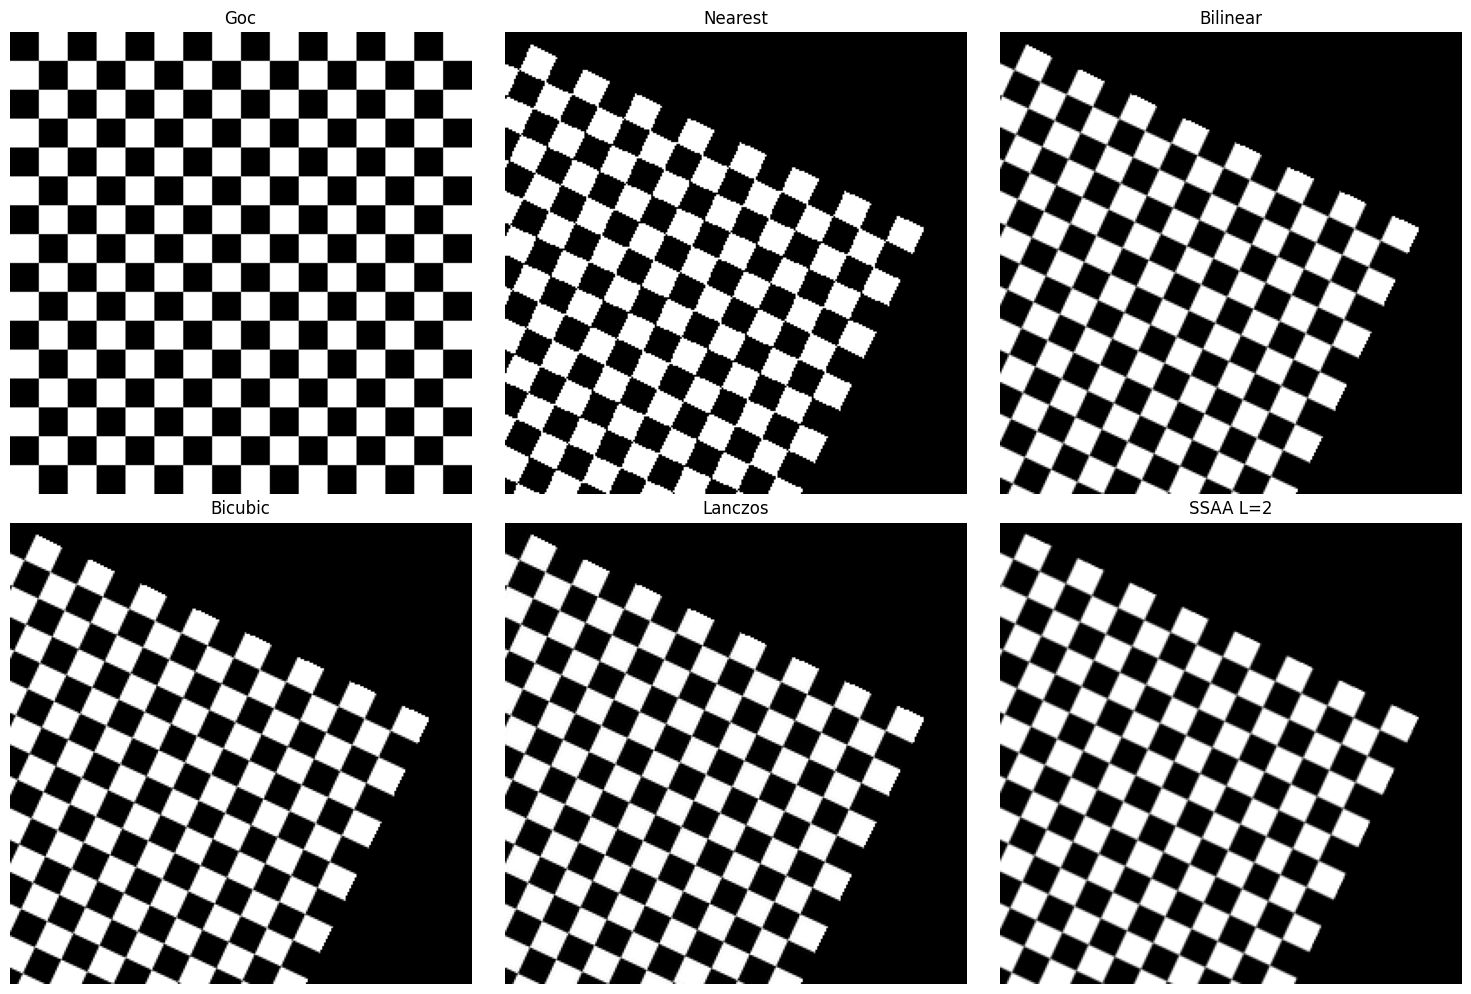

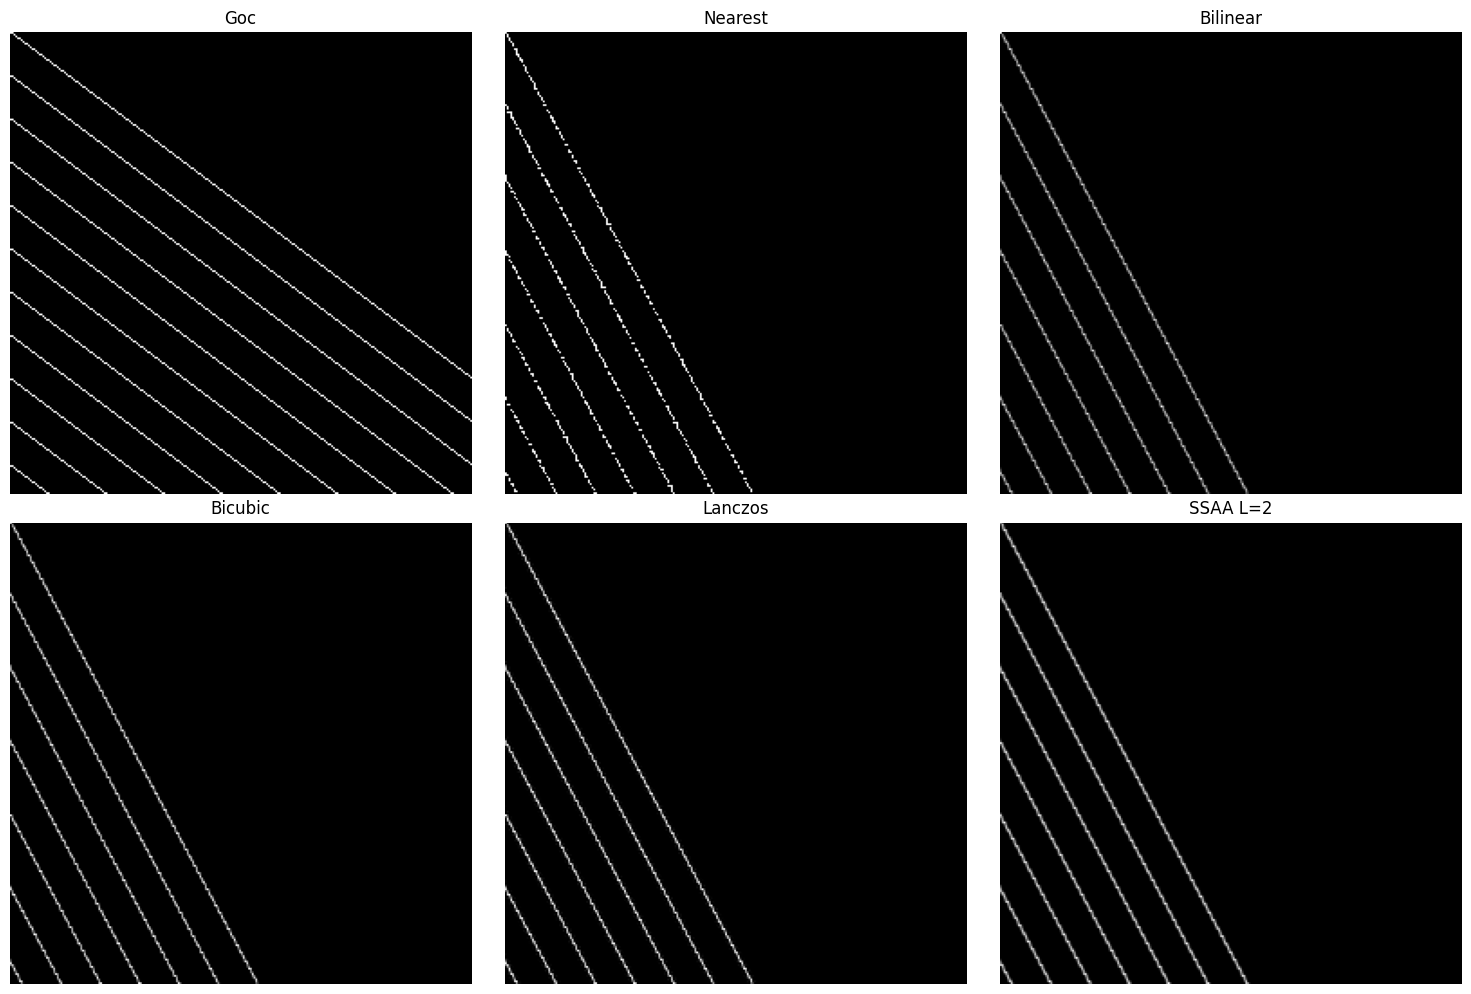

In [31]:
# Ô thực hành so sánh anti-aliasing
# Sau khi hoàn thiện tất cả các hàm, chạy so sánh ở đây.

# Ví dụ khung:
# M = rotation_matrix(25)
# H, W = checkerboard_img.shape
# img_f = checkerboard_img.astype(np.float32)
#
# out_nn  = warp_affine_manual(img_f, M, (H, W), interpolation='nearest')
# out_bl  = warp_affine_manual(img_f, M, (H, W), interpolation='bilinear')
# out_bc  = warp_affine_manual(img_f, M, (H, W), interpolation='bicubic')
# out_lz  = warp_affine_manual(img_f, M, (H, W), interpolation='lanczos')
# out_ss  = warp_affine_ssaa(img_f, M, (H, W), L=2)
#
# show_images(
#     [checkerboard_img, out_nn, out_bl, out_bc, out_lz, out_ss],
#     titles=['Gốc', 'Nearest', 'Bilinear', 'Bicubic', 'Lanczos', 'SSAA L=2'],
#     cols=3, figsize=(15, 10)
# )

# Khoi tao ma tran xoay 25 do va cau hinh kich thuoc
M = rotation_matrix(25)
H, W = checkerboard_img.shape

# Ep kieu anh kiem thu sang float32 de dam bao chat luong noi suy
img_cb = checkerboard_img.astype(np.float32)
img_dg = diagonal_img.astype(np.float32)

# so sanh tren anh ban co
out_nn_cb = warp_affine_manual(img_cb, M, (H, W), interpolation='nearest')
out_bl_cb = warp_affine_manual(img_cb, M, (H, W), interpolation='bilinear')
out_bc_cb = warp_affine_manual(img_cb, M, (H, W), interpolation='bicubic')
out_lz_cb = warp_affine_manual(img_cb, M, (H, W), interpolation='lanczos')
out_ss_cb = warp_affine_ssaa(img_cb, M, (H, W), L=2)

show_images(
    [checkerboard_img, out_nn_cb, out_bl_cb, out_bc_cb, out_lz_cb, out_ss_cb],
    titles=['Goc', 'Nearest', 'Bilinear', 'Bicubic', 'Lanczos', 'SSAA L=2'],
    cols=3, figsize=(15, 10)
)

# so sanh tren anh duong cheo manh
out_nn_dg = warp_affine_manual(img_dg, M, (H, W), interpolation='nearest')
out_bl_dg = warp_affine_manual(img_dg, M, (H, W), interpolation='bilinear')
out_bc_dg = warp_affine_manual(img_dg, M, (H, W), interpolation='bicubic')
out_lz_dg = warp_affine_manual(img_dg, M, (H, W), interpolation='lanczos')
out_ss_dg = warp_affine_ssaa(img_dg, M, (H, W), L=2)

show_images(
    [diagonal_img, out_nn_dg, out_bl_dg, out_bc_dg, out_lz_dg, out_ss_dg],
    titles=['Goc', 'Nearest', 'Bilinear', 'Bicubic', 'Lanczos', 'SSAA L=2'],
    cols=3, figsize=(15, 10)
)

*(Sinh viên viết nhận xét so sánh ở đây)*

Sau khi thực nghiệm xoay hai ảnh checkerboard và diagonal một góc 25 độ bằng 5 phương pháp, em rút ra các nhận xét sau:
1. Hiện tượng răng cưa (Aliasing)
Tốt nhất: Lanczos và SSAA (L=2) cho kết quả mượt nhất, gần như loại bỏ hoàn toàn hiện tượng răng cưa.
Lanczos đạt được điều này nhờ sử dụng hàm sinc cửa sổ hóa để tái tạo tín hiệu.
SSAA giảm aliasing bằng cách lấy nhiều mẫu con trên mỗi pixel.
Kém nhất: Nearest-neighbor tạo răng cưa rõ rệt do chỉ làm tròn tọa độ pixel mà không có bước nội suy, khiến các cạnh chéo bị bậc thang hóa.
2. Độ mờ (Blurring) và hiệu ứng Halo
Bilinear: Làm mờ cạnh ở mức trung bình do nội suy tuyến tính trên vùng 2×2.
Bicubic: Giữ cạnh tốt hơn Bilinear nhờ kernel bậc ba có thành phần âm, giúp tăng độ sắc nét cục bộ.
Lanczos:
Cho độ sắc nét cao nhất
Tuy nhiên xuất hiện hiệu ứng ringing (halo) ở vùng tương phản mạnh (đen–trắng), do đặc tính dao động của hàm sinc.
3. Chi phí tính toán
- Nearest: ~1 phép nhân/pixel
- Bilinear: ~4 phép nhân/pixel
- Bicubic: ~16 phép nhân/pixel
- SSAA (L=2): ~16 phép nhân/pixel
- Lanczos (a=3): ~36 phép nhân/pixel
4. Ứng dụng thực tế

* Ảnh y tế (X-ray, MRI, CT):
    * Ưu tiên Bicubic hoặc SSAA
    * Vì cần bảo toàn biên chính xác, tránh tạo artefact giả
    * Không nên dùng Lanczos do hiệu ứng halo có thể gây hiểu nhầm trong chẩn đoán
* Ảnh tự nhiên (phong cảnh, chân dung):
    * Lanczos là lựa chọn tốt nhất
    * Mang lại hình ảnh sắc nét, chi tiết cao
    * Hiệu ứng ringing thường khó nhận thấy trong ảnh thực tế

# Checklist trước khi nộp bài

**Bài tập 1 -- Hình thái học**
- [X] Đã tự viết hàm padding.
- [X] Đã tự viết hàm tạo phần tử cấu trúc (rectangle, cross, ellipse).
- [X] Đã tự viết erosion, dilation, opening, closing, gradient.
- [X] Đã thử trên ảnh nhị phân kiểm thử và ảnh mẫu giảng viên.
- [X] Đã có phần nhận xét cho từng kết quả hình thái học.

**Bài tập 2 -- Biến đổi hình học và Anti-aliasing**
- [x] Đã tự viết `convolve2d_manual` bằng vòng lặp (không dùng hàm có sẵn).
- [x] Đã tự viết `nearest_interpolate` và `bilinear_interpolate`.
- [x] Đã tự viết `bicubic_interpolate` (cubic_kernel + 4×4 window).
- [x] Đã tự viết `lanczos_interpolate` (lanczos_kernel + (2a)×(2a) window).
- [x] Đã tự viết `warp_affine_ssaa` với supersampling.
- [x] Đã tự viết `warp_affine_manual` tích hợp đủ bốn phương pháp nội suy.
- [x] Đã so sánh tất cả kỹ thuật trên cùng một phép biến đổi.
- [x] Đã trả lời đủ bốn câu hỏi nhận xét trong phần so sánh.
- [x] Đã dùng ảnh mẫu của giảng viên trong bài nộp chính thức.
- [x] Đã tuân thủ các hàm bị cấm.
